In [67]:
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use("default")   # quay về style mặc định (nền trắng)

# set defaults for matplotlib
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Cấu hình font Times New Roman
plt.rcParams['font.family'] = 'Dejavu serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Để hiển thị math text đúng
plt.rcParams['font.size'] = 12  # Font size mặc định

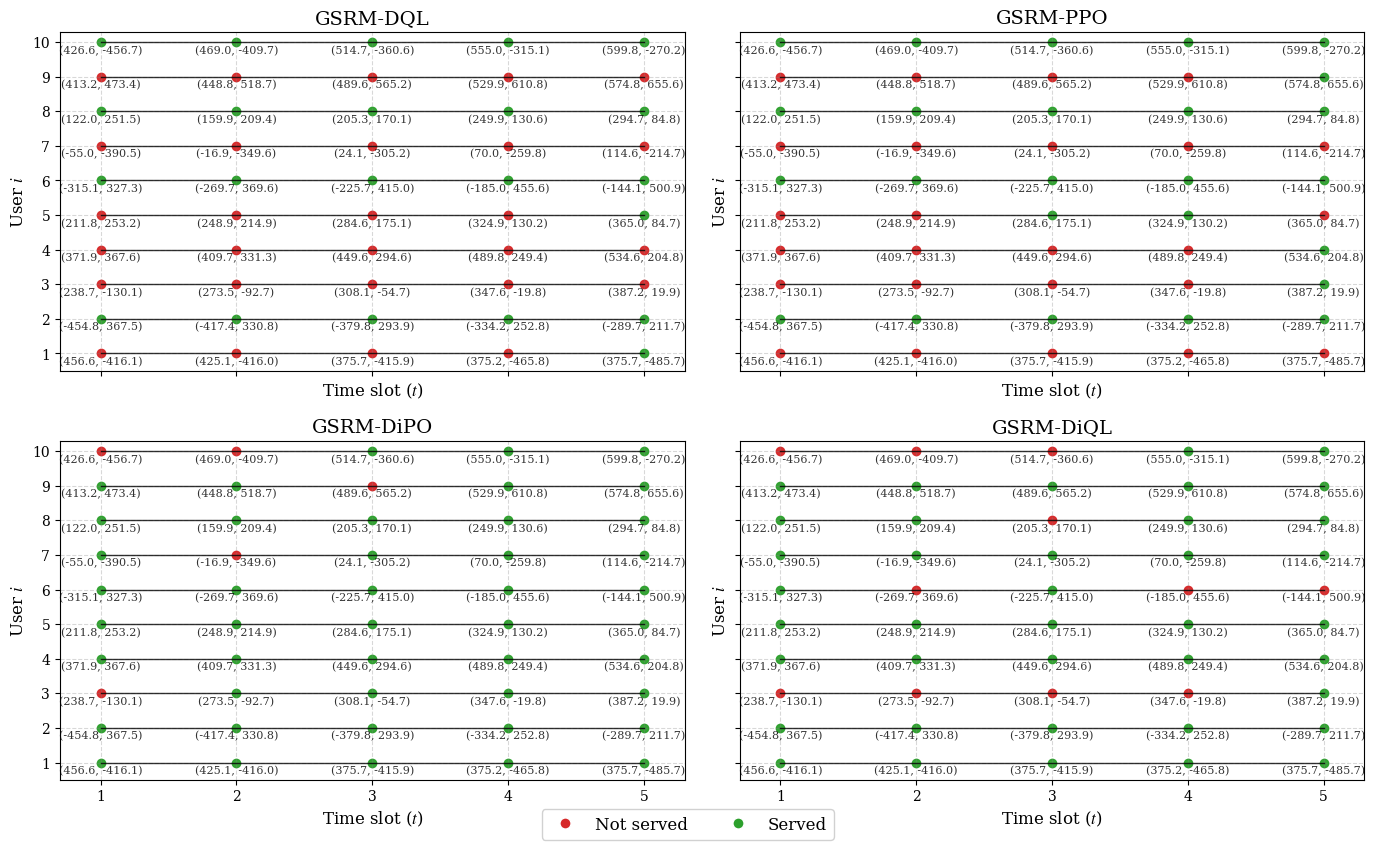

In [68]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

base_dir = Path("outputs")
merged_file = base_dir / "mobility_timestep_user_all_agents_ep_5.csv"

served_columns = {
    "gaussian_dql": "served_gaussian_dql",
    "gaussian_ppo": "served_gaussian_ppo",
    "ppo_diffusion": "served_ppo_diffusion",
    "ql_diffusion": "served_ql_diffusion",
}

agent_names_display = {
    "ppo_diffusion": "GSRM-DiPO",
    "ql_diffusion": "GSRM-DiQL",
    "gaussian_ppo": "GSRM-PPO",
    "gaussian_dql": "GSRM-DQL",
}

df_all = pd.read_csv(merged_file)
df_all["timestep"] = df_all["timestep"].astype(int)
df_all["user_id_1based"] = df_all["user_id_1based"].astype(int)

for col in served_columns.values():
    if col in df_all.columns and df_all[col].dtype != bool:
        df_all[col] = df_all[col].astype(str).str.lower().isin(["true", "1", "yes"])

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.ravel()

for ax, agent in zip(axes, served_columns.keys()):
    col = served_columns[agent]
    if col not in df_all.columns:
        ax.set_title(f"{agent} (missing column: {col})")
        ax.axis("off")
        continue

    df = df_all[["timestep", "user_id_1based", "x", "y", col]].copy()
    df = df.rename(columns={col: "served"}).sort_values(["user_id_1based", "timestep"])

    for uid, g in df.groupby("user_id_1based"):
        ax.plot(g["timestep"], g["user_id_1based"], color="black", linewidth=1, alpha=0.8)

    not_served = df[~df["served"]]
    served = df[df["served"]]
    ax.scatter(not_served["timestep"], not_served["user_id_1based"], c="tab:red", s=36, alpha=0.95)
    ax.scatter(served["timestep"], served["user_id_1based"], c="tab:green", s=36, alpha=0.95)

    for _, r in df.iterrows():
        ax.text(
            r["timestep"],
            r["user_id_1based"] - 0.08,
            f"({r['x']:.1f}, {r['y']:.1f})",
            fontsize=8,
            alpha=0.8,
            ha="center",
            va="top",
        )

    ax.set_title(agent_names_display.get(agent, agent))
    ax.set_xlabel(r"Time slot ($t$)")
    ax.set_ylabel(r"User $i$")
    ax.grid(alpha=0.3)

    ts = sorted(df["timestep"].unique().tolist())
    uids = sorted(df["user_id_1based"].unique().tolist())
    ax.set_xticks(ts)
    ax.set_yticks(uids)
    ax.set_xlim(min(ts)-0.3, max(ts)+0.3)
    ax.set_ylim(min(uids) - 0.5, max(uids) + 0.3)


for i in range(len(served_columns), len(axes)):
    axes[i].axis("off")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Not served', markerfacecolor='tab:red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Served', markerfacecolor='tab:green', markersize=8),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

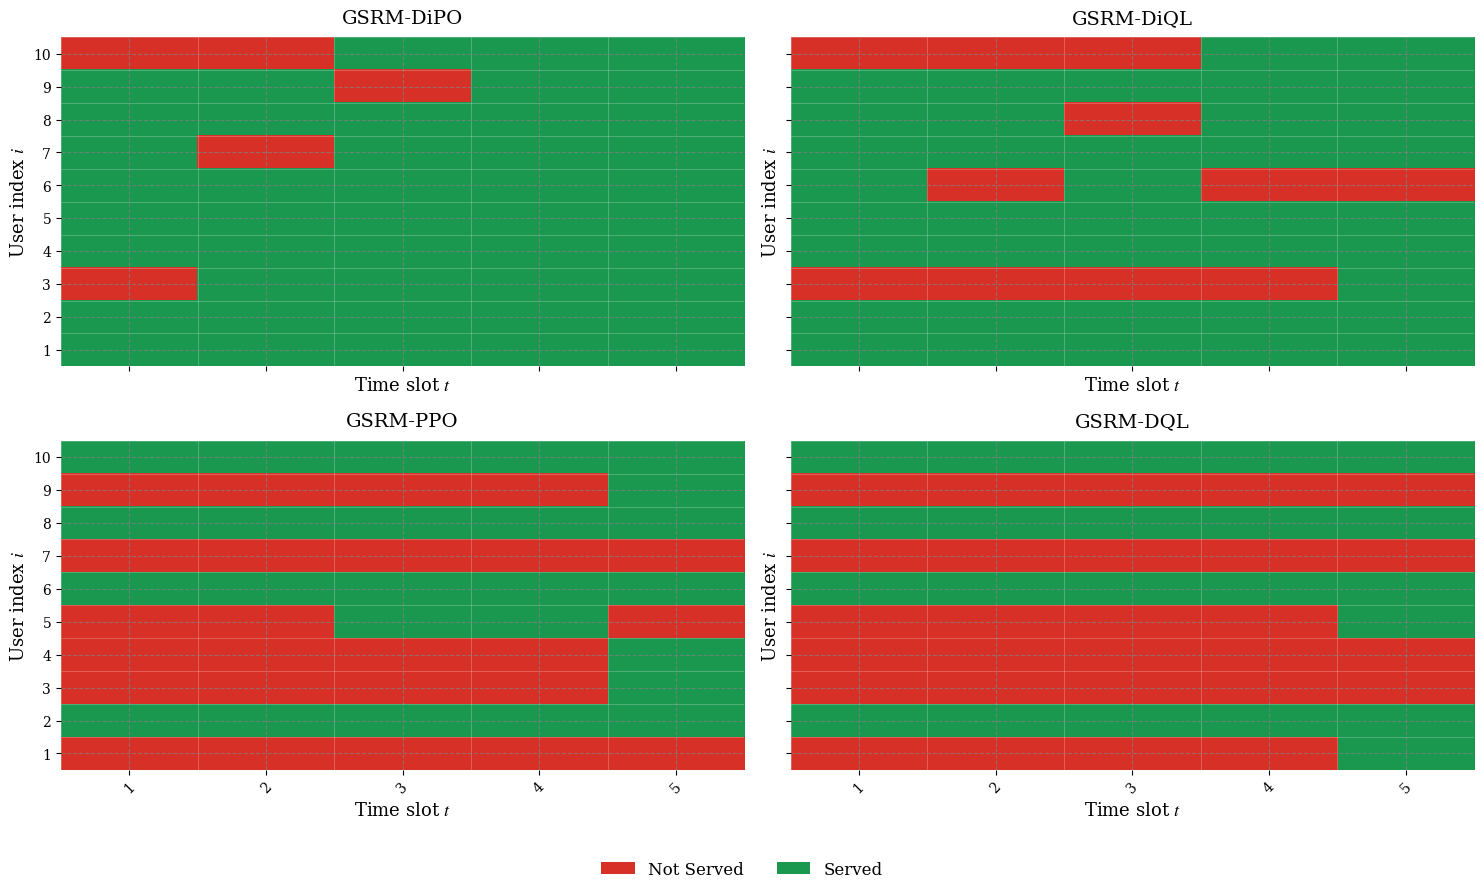

In [69]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

base_dir = Path("outputs")
merged_file = base_dir / "mobility_timestep_user_all_agents_ep_5.csv"

served_columns = {
    "ppo_diffusion": "served_ppo_diffusion",
    "ql_diffusion": "served_ql_diffusion",
    "gaussian_ppo": "served_gaussian_ppo",
    "gaussian_dql": "served_gaussian_dql",
}

agent_names_display = {
    "ppo_diffusion": "GSRM-DiPO",
    "ql_diffusion": "GSRM-DiQL",
    "gaussian_ppo": "GSRM-PPO",
    "gaussian_dql": "GSRM-DQL",
}

df_all = pd.read_csv(merged_file)
df_all["timestep"] = df_all["timestep"].astype(int)
df_all["user_id_1based"] = df_all["user_id_1based"].astype(int)

for col in served_columns.values():
    if col in df_all.columns and df_all[col].dtype != bool:
        df_all[col] = df_all[col].astype(str).str.lower().isin(["true", "1", "yes"])

# soft academic red/green
cmap = ListedColormap(["#d73027", "#1a9850"])

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True, sharey=True)
axes = axes.ravel()

all_ts = sorted(df_all["timestep"].unique())
all_uids = sorted(df_all["user_id_1based"].unique())

for ax, agent in zip(axes, served_columns.keys()):
    col = served_columns[agent]
    df = df_all[["timestep", "user_id_1based", col]].copy()
    df = df.rename(columns={col: "served"})
    df["served_int"] = df["served"].astype(int)

    mat = (
        df.pivot_table(
            index="user_id_1based",
            columns="timestep",
            values="served_int",
            aggfunc="max",
            fill_value=0,
        )
        .reindex(index=all_uids, columns=all_ts, fill_value=0)
    )

    im = ax.imshow(
        mat.values,
        cmap=cmap,
        vmin=0,
        vmax=1,
        aspect="auto",
        origin="lower",
        interpolation="nearest",
    )

    ax.set_title(agent_names_display[agent], pad=10)
    ax.set_xlabel(r"Time slot $t$")
    ax.set_ylabel(r"User index $i$")

    # reduce tick density (only show every k ticks if large)
    step_x = max(1, len(all_ts)//10)
    step_y = max(1, len(all_uids)//10)

    ax.set_xticks(np.arange(0, len(all_ts), step_x))
    ax.set_xticklabels(all_ts[::step_x], rotation=45)

    ax.set_yticks(np.arange(0, len(all_uids), step_y))
    ax.set_yticklabels(all_uids[::step_y])

    # subtle grid
    ax.set_xticks(np.arange(-.5, len(all_ts), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(all_uids), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=0.4, alpha=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    # remove frame
    for spine in ax.spines.values():
        spine.set_visible(False)

# global legend
legend_elements = [
    Patch(facecolor='#d73027', label='Not Served'),
    Patch(facecolor='#1a9850', label='Served'),
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=2,
    frameon=False,
    fontsize=12
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()


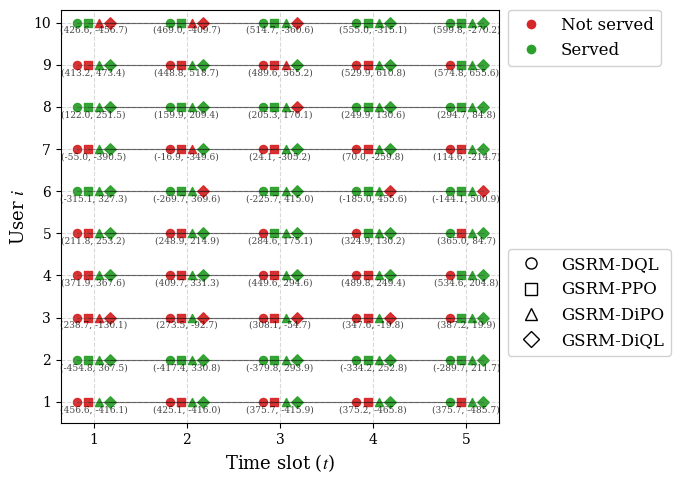

In [70]:
# Version: legends outside the plot area
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

base_dir = Path("outputs")
merged_file = base_dir / "mobility_timestep_user_all_agents_ep_5.csv"

served_columns = {
    "gaussian_dql": "served_gaussian_dql",
    "gaussian_ppo": "served_gaussian_ppo",
    "ppo_diffusion": "served_ppo_diffusion",
    "ql_diffusion": "served_ql_diffusion",
}

agent_names_display = {
    "ppo_diffusion": "GSRM-DiPO",
    "ql_diffusion": "GSRM-DiQL",
    "gaussian_ppo": "GSRM-PPO",
    "gaussian_dql": "GSRM-DQL",
}

agent_markers = {
    "gaussian_dql": "o",
    "gaussian_ppo": "s",
    "ppo_diffusion": "^",
    "ql_diffusion": "D",
}

agent_dx = {
    "gaussian_dql": -0.18,
    "gaussian_ppo": -0.06,
    "ppo_diffusion": 0.06,
    "ql_diffusion": 0.18,
}

df_all = pd.read_csv(merged_file)
df_all["timestep"] = df_all["timestep"].astype(int)
df_all["user_id_1based"] = df_all["user_id_1based"].astype(int)

for col in served_columns.values():
    if col in df_all.columns and df_all[col].dtype != bool:
        df_all[col] = df_all[col].astype(str).str.lower().isin(["true", "1", "yes"])

fig, ax = plt.subplots(1, 1, figsize=(9, 5))

for agent in served_columns.keys():
    col = served_columns[agent]
    if col not in df_all.columns:
        continue

    marker = agent_markers.get(agent, "o")
    dx = agent_dx.get(agent, 0.0)

    df = df_all[["timestep", "user_id_1based", "x", "y", col]].copy()
    df = df.rename(columns={col: "served"}).sort_values(["user_id_1based", "timestep"])

    for uid, g in df.groupby("user_id_1based"):
        ax.plot(g["timestep"] + dx, g["user_id_1based"], color="black", linewidth=0.8, alpha=0.18)

    not_served = df[~df["served"]]
    served = df[df["served"]]

    ax.scatter(not_served["timestep"] + dx, not_served["user_id_1based"], marker=marker, c="tab:red", s=34, alpha=0.95)
    ax.scatter(served["timestep"] + dx, served["user_id_1based"], marker=marker, c="tab:green", s=34, alpha=0.95)

base_labels = (
    df_all[["timestep", "user_id_1based", "x", "y"]]
    .drop_duplicates(subset=["timestep", "user_id_1based"])
    .sort_values(["user_id_1based", "timestep"])
)
for _, r in base_labels.iterrows():
    ax.text(r["timestep"], r["user_id_1based"] - 0.08, f"({r['x']:.1f}, {r['y']:.1f})", fontsize=6.5, alpha=0.72, ha="center", va="top")

ax.set_xlabel(r"Time slot ($t$)")
ax.set_ylabel(r"User $i$")
ax.grid(alpha=0.3)

ts = sorted(df_all["timestep"].unique().tolist())
uids = sorted(df_all["user_id_1based"].unique().tolist())
ax.set_xticks(ts)
ax.set_yticks(uids)
ax.set_xlim(min(ts) - 0.35, max(ts) + 0.35)
ax.set_ylim(min(uids) - 0.5, max(uids) + 0.3)

status_legend = [
    Line2D([0], [0], marker='o', color='w', label='Not served', markerfacecolor='tab:red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Served', markerfacecolor='tab:green', markersize=8),
]
leg1 = ax.legend(handles=status_legend, loc='upper left', bbox_to_anchor=(1.02, 1.00), borderaxespad=0.0, frameon=True)
ax.add_artist(leg1)

agent_legend = [
    Line2D([0], [0], marker=agent_markers[a], color='black', linestyle='None', markerfacecolor='white', markeredgecolor='black', markersize=8, label=agent_names_display.get(a, a))
    for a in served_columns.keys()
]
ax.legend(handles=agent_legend, loc='upper left', bbox_to_anchor=(1.02, 0.42), borderaxespad=0.0, frameon=True)

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

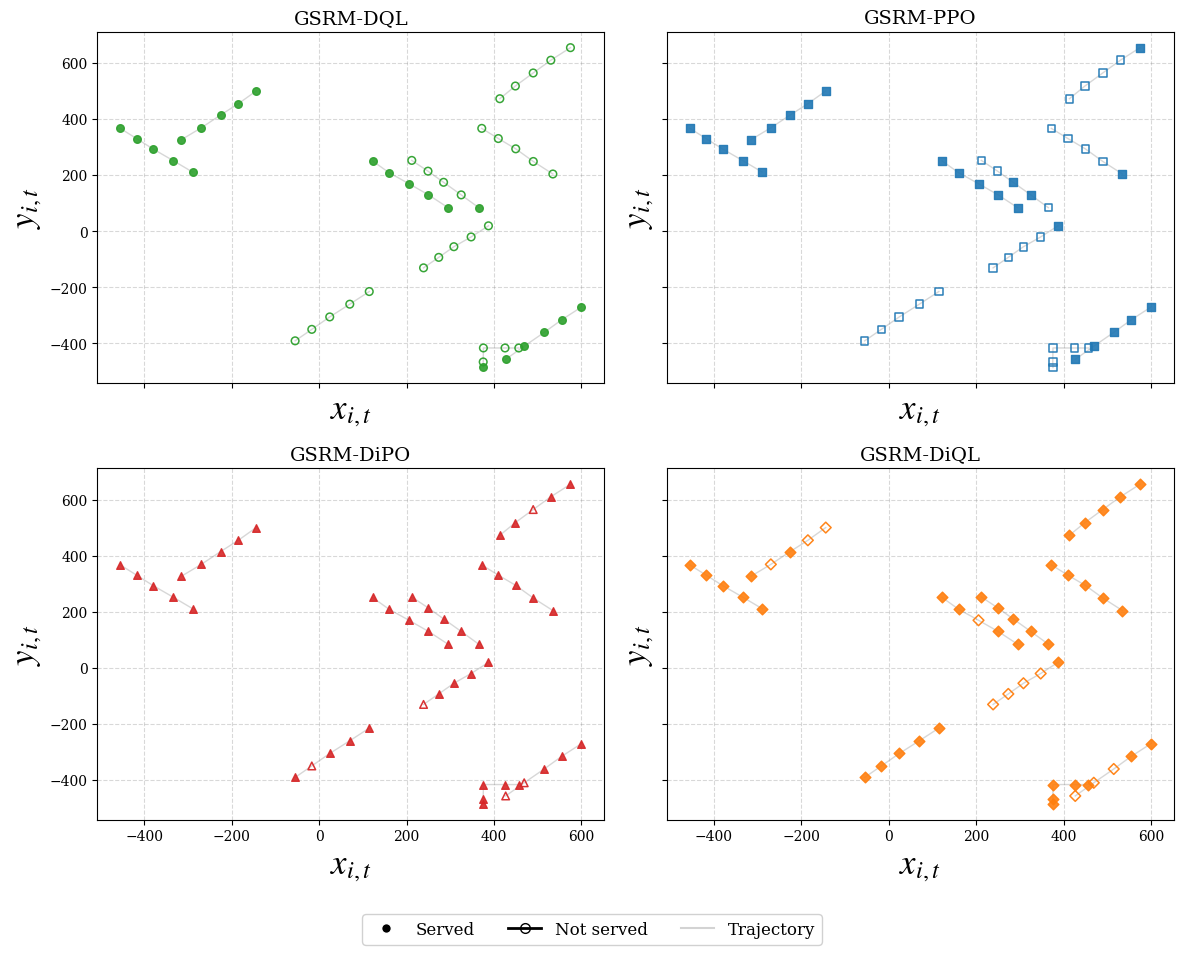

In [71]:
# Cell mới: tách thành 4 hình (2x2), mỗi agent 1 subplot theo vị trí (x, y)
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# Fallback nếu chưa có biến từ các cell trước
if "df_all" not in globals() or "served_columns" not in globals() or "agent_names_display" not in globals():
    base_dir = Path("outputs")
    merged_file = base_dir / "mobility_timestep_user_all_agents_ep_5.csv"
    assert merged_file.exists(), f"Missing merged file: {merged_file}"
    df_all = pd.read_csv(merged_file)
    served_columns = {
        "gaussian_dql": "served_gaussian_dql",
        "gaussian_ppo": "served_gaussian_ppo",
        "ppo_diffusion": "served_ppo_diffusion",
        "ql_diffusion": "served_ql_diffusion",
    }
    agent_names_display = {
        "ppo_diffusion": "GSRM-DiPO",
        "ql_diffusion": "GSRM-DiQL",
        "gaussian_ppo": "GSRM-PPO",
        "gaussian_dql": "GSRM-DQL",
    }

agent_styles = {
    "gaussian_dql": {"color": "tab:green", "marker": "o"},
    "gaussian_ppo": {"color": "tab:blue", "marker": "s"},
    "ppo_diffusion": {"color": "tab:red", "marker": "^"},
    "ql_diffusion": {"color": "tab:orange", "marker": "D"},
}

for col in served_columns.values():
    if col in df_all.columns and df_all[col].dtype != bool:
        df_all[col] = df_all[col].astype(str).str.lower().isin(["true", "1", "yes"])

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.ravel()

x_min, x_max = df_all["x"].min(), df_all["x"].max()
y_min, y_max = df_all["y"].min(), df_all["y"].max()
x_pad = max(0.5, 0.05 * (x_max - x_min + 1e-9))
y_pad = max(0.5, 0.05 * (y_max - y_min + 1e-9))

base_traj = df_all[["timestep", "user_id_1based", "x", "y"]].sort_values(["user_id_1based", "timestep"])

for ax, agent in zip(axes, served_columns.keys()):
    col = served_columns[agent]
    style = agent_styles.get(agent, {"color": "tab:blue", "marker": "o"})

    if col not in df_all.columns:
        ax.set_title(f"{agent_names_display.get(agent, agent)} (missing: {col})")
        ax.axis("off")
        continue

    # Vẽ trajectory nền (giống nhau giữa các agent)
    for _, g in base_traj.groupby("user_id_1based"):
        ax.plot(g["x"], g["y"], color="lightgray", linewidth=1.0, alpha=0.9, zorder=1)

    df = df_all[["x", "y", col]].copy().rename(columns={col: "served"})
    served = df[df["served"]]
    not_served = df[~df["served"]]

    # served: marker fill
    ax.scatter(
        served["x"],
        served["y"],
        s=30,
        marker=style["marker"],
        c=style["color"],
        alpha=0.9,
        zorder=3,
    )

    # not served: marker rỗng
    ax.scatter(
        not_served["x"],
        not_served["y"],
        s=30,
        marker=style["marker"],
        facecolors="none",
        edgecolors=style["color"],
        linewidths=1.1,
        alpha=0.95,
        zorder=2,
    )

    ax.set_title(agent_names_display.get(agent, agent), fontsize=14)
    ax.set_xlabel(r"$x_{i,t}$", fontsize=25)
    ax.set_ylabel(r"$y_{i,t}$", fontsize=25)
    ax.grid(alpha=0.3)
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

for i in range(len(served_columns), len(axes)):
    axes[i].axis("off")

status_legend = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black", markersize=7, label="Served"),
    Line2D([0], [0], marker="o", color="black", markerfacecolor="none", markersize=7, label="Not served"),
    Line2D([0], [0], color="lightgray", lw=1.5, label="Trajectory"),
]
fig.legend(handles=status_legend, loc="lower center", ncol=3, frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

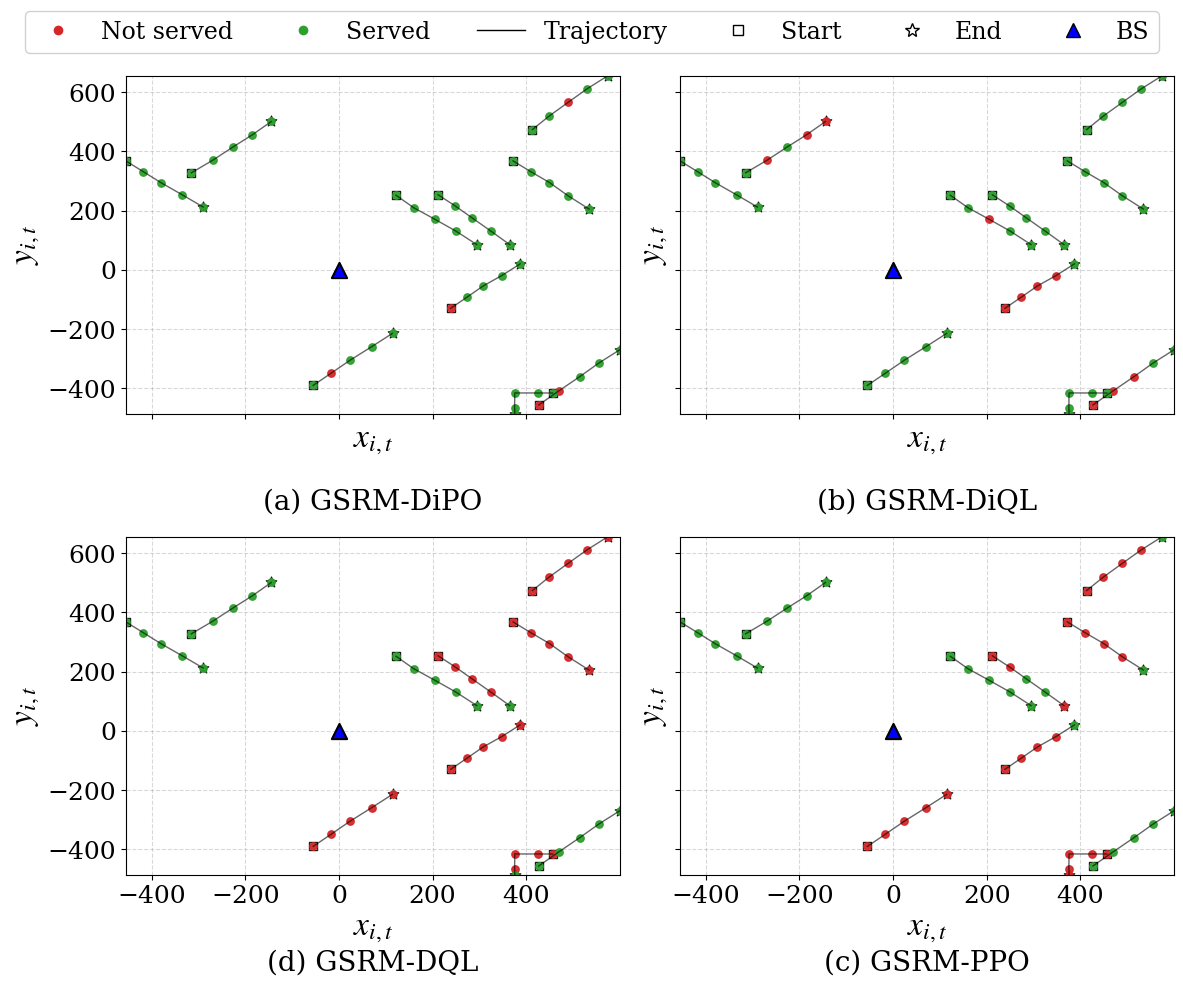

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['font.size'] = 18
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['axes.labelsize'] = 22
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['legend.fontsize'] = 18


# Cấu hình font Times New Roman
plt.rcParams['font.family'] = 'Dejavu serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Để hiển thị math text đúng
plt.rcParams['font.size'] = 12  # Font size mặc định

base_dir = Path("outputs")
merged_file = base_dir / "mobility_timestep_user_all_agents_ep_5.csv"
df_all = pd.read_csv(merged_file)
served_columns = {
    "ppo_diffusion": "served_ppo_diffusion",
    "ql_diffusion": "served_ql_diffusion",
    "gaussian_dql": "served_gaussian_dql",
    "gaussian_ppo": "served_gaussian_ppo",
}
agent_names_display = {
    "ppo_diffusion": "(a) GSRM-DiPO",
    "ql_diffusion": "(b) GSRM-DiQL",
    "gaussian_ppo": "(c) GSRM-PPO",
    "gaussian_dql": "(d) GSRM-DQL",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, agent in zip(axes, served_columns.keys()):
    col = served_columns[agent]
    if col not in df_all.columns:
        ax.set_title(f"{agent} (missing: {col})")
        ax.axis("off")
        continue

    df = df_all[["timestep", "user_id_1based", "x", "y", col]].copy()
    if df[col].dtype != bool:
        df[col] = df[col].astype(str).str.lower().isin(["true", "1", "yes"])
    df = df.rename(columns={col: "served"}).sort_values(["user_id_1based", "timestep"])

    for uid, g in df.groupby("user_id_1based"):
        ax.plot(g["x"], g["y"], color="black", linewidth=1, alpha=0.6)

        g2 = g.sort_values("timestep")
        ax.scatter(g2.iloc[0]["x"], g2.iloc[0]["y"], marker="s", s=30, alpha=0.9, edgecolor="black", facecolor="white")
        ax.scatter(g2.iloc[-1]["x"], g2.iloc[-1]["y"], marker="*", s=60, alpha=0.9, edgecolor="black", facecolor="white")
    ax.scatter(
        0, 0,
        marker="^",
        s=120,
        c="blue",
        edgecolor="black",
        linewidth=1.5,
        zorder=5
    )

    not_served = df[~df["served"]]
    served = df[df["served"]]
    ax.scatter(not_served["x"], not_served["y"], c="tab:red", s=28, alpha=0.95)
    ax.scatter(served["x"], served["y"], c="tab:green", s=28, alpha=0.95)

    # ax.set_title(agent_names_display.get(agent, agent), fontsize=14)
    ax.text(
        0.5, -0.30,   # (x_center, dưới trục)
        agent_names_display.get(agent, agent),
        transform=ax.transAxes,
        ha='center',
        va='bottom',
        fontsize=20
    )
    ax.set_xlabel(r"$x_{i,t}$", fontsize=24)
    ax.set_ylabel(r"$y_{i,t}$", fontsize=24)
    ax.set_xlim(df["x"].min(), df["x"].max())
    ax.set_ylim(df["y"].min(), df["y"].max())
    ax.grid(alpha=0.3)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Not served', markerfacecolor='tab:red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Served', markerfacecolor='tab:green', markersize=8),
    Line2D([0], [0], color='black', lw=1, label='Trajectory'),
    Line2D([0], [0], marker='s', color='w', label='Start', markeredgecolor='black', markersize=7, markeredgewidth=1),
    Line2D([0], [0], marker='*', color='w', label='End', markeredgecolor='black', markersize=10, markeredgewidth=1),
    Line2D([0], [0], marker='^', color='w', label='BS', markerfacecolor='blue', markeredgecolor='black', markersize=10),

]

# markeredgecolor='black', markeredgewidth=1.5, markersize=7
fig.legend(handles=legend_elements, loc='upper center', ncol=6, frameon=True, fontsize=17)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()